# Titanic Dataset — Statistical Analysis
Descriptive Statistics · Probability Distributions · Hypothesis Testing · Correlation vs Causation

### 1. Setup and Import

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 1. Load cleaned Dataset
- `Ticket` column was dropped (not useful for stats)

In [2]:
df_clean = pd.read_csv(r"C:\Users\Student\Downloads\titanic_cleaned.csv")
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,Unknown,S


## 2. Descriptive Statistics
Mean, variance, standard deviation, and other summary stats for the key numeric variables.

In [3]:
desc_cols = ["Age", "Fare", "SibSp", "Parch"]
desc_stats = pd.DataFrame({
    "mean": df_clean[desc_cols].mean(),
    "variance": df_clean[desc_cols].var(),
    "std_dev": df_clean[desc_cols].std(),
    "median": df_clean[desc_cols].median(),
    "min": df_clean[desc_cols].min(),
    "max": df_clean[desc_cols].max(),
})
desc_stats.round(2)

,mean,variance,std_dev,median,min,max
Age,29.36,169.51,13.02,28.00,0.42,80.00
Fare,32.20,2469.44,49.69,14.45,0.00,512.33
SibSp,0.52,1.22,1.10,0.00,0.00,8.00
Parch,0.38,0.65,0.81,0.00,0.00,6.00


In [4]:
survival_rate = df_clean["Survived"].mean()
print(f"Overall survival rate: {survival_rate:.3f}")
print("\nSurvival rate by Pclass:\n", df_clean.groupby("Pclass")["Survived"].mean().round(3))
print("\nSurvival rate by Sex:\n", df_clean.groupby("Sex")["Survived"].mean().round(3))

Overall survival rate: 0.384

Survival rate by Pclass:
 Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

Survival rate by Sex:
 Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


**Visualize the Age and Fare distributions:**

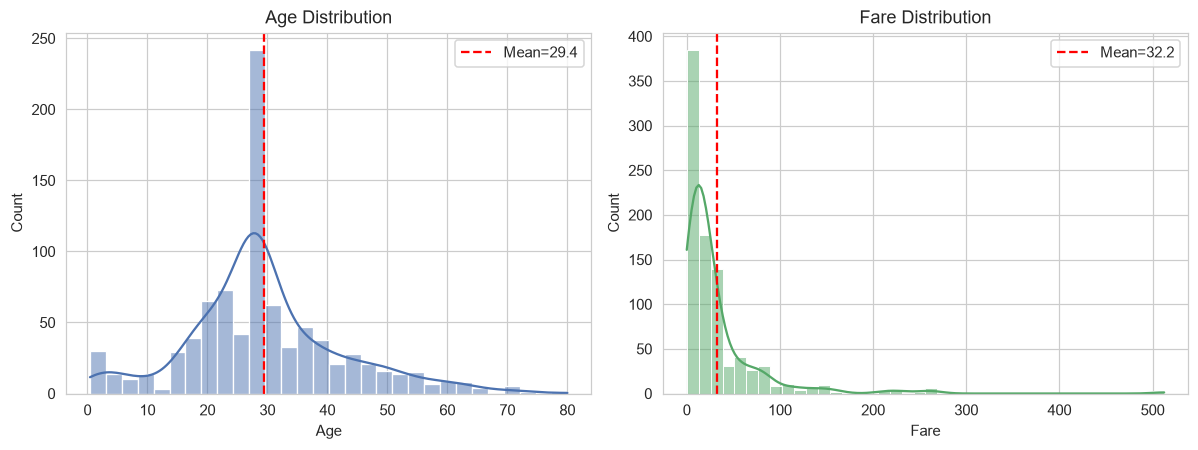

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.histplot(df_clean["Age"], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Age Distribution")
axes[0].axvline(df_clean["Age"].mean(), color="red", linestyle="--",
                 label=f"Mean={df_clean['Age'].mean():.1f}")
axes[0].legend()

sns.histplot(df_clean["Fare"], bins=40, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Fare Distribution")
axes[1].axvline(df_clean["Fare"].mean(), color="red", linestyle="--",
                 label=f"Mean={df_clean['Fare'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("dist_age_fare.png")
plt.show()

## 3. Probability Distributions
- `Survived` is binary → modeled as **Bernoulli(p)**, with repeated sampling to visualize the resulting **Binomial** distribution
- `Age` is continuous → checked against a fitted **Normal** distribution, tested with Shapiro-Wilk

In [6]:
p_survive = df_clean["Survived"].mean()
theoretical_var = p_survive * (1 - p_survive)
observed_var = df_clean["Survived"].var()

print(f"Survived ~ Bernoulli(p={p_survive:.3f})")
print(f"Theoretical variance p(1-p) = {theoretical_var:.3f}")
print(f"Observed variance           = {observed_var:.3f}")

Survived ~ Bernoulli(p=0.384)
Theoretical variance p(1-p) = 0.237
Observed variance           = 0.237


In [7]:
# Simulate Binomial(n=50, p=p_survive) by resampling
n_trials, n_sim = 50, 1000
sim_survivors = np.random.binomial(n_trials, p_survive, n_sim)

# Fit Normal distribution to Age
age_mu, age_sigma = df_clean["Age"].mean(), df_clean["Age"].std()
shapiro_age = stats.shapiro(df_clean["Age"].sample(min(500, len(df_clean)), random_state=1))

print(f"Age ~ approx Normal(mu={age_mu:.2f}, sigma={age_sigma:.2f})")
print(f"Shapiro-Wilk test: W={shapiro_age.statistic:.4f}, p={shapiro_age.pvalue:.4g}")

Age ~ approx Normal(mu=29.36, sigma=13.02)
Shapiro-Wilk test: W=0.9493, p=4.589e-12


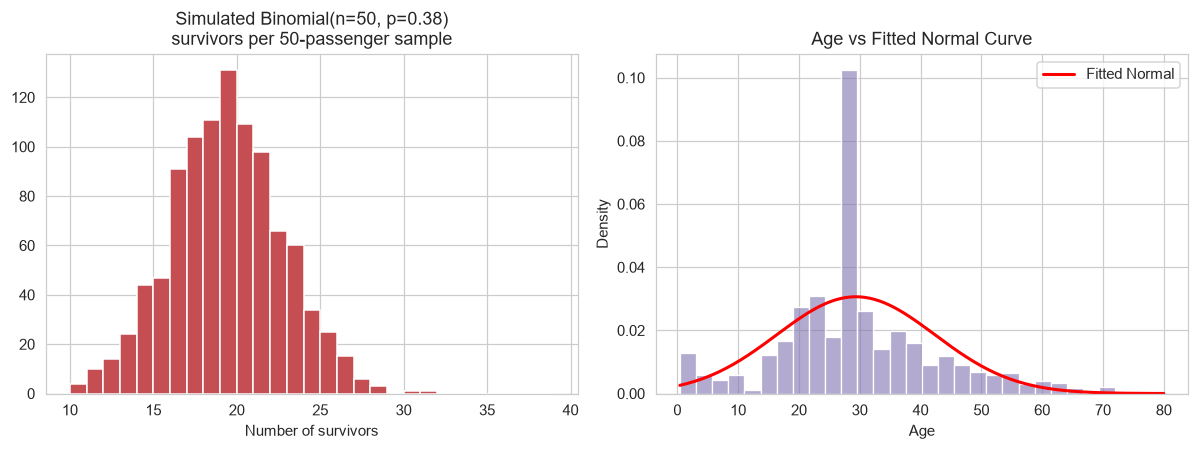

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(sim_survivors, bins=range(10, 40), color="#C44E52", edgecolor="white")
axes[0].set_title(f"Simulated Binomial(n={n_trials}, p={p_survive:.2f})\nsurvivors per 50-passenger sample")
axes[0].set_xlabel("Number of survivors")

sns.histplot(df_clean["Age"], bins=30, stat="density", ax=axes[1], color="#8172B2", alpha=0.6)
x = np.linspace(df_clean["Age"].min(), df_clean["Age"].max(), 200)
axes[1].plot(x, stats.norm.pdf(x, age_mu, age_sigma), "r-", lw=2, label="Fitted Normal")
axes[1].set_title("Age vs Fitted Normal Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("prob_distributions.png")
plt.show()

## 4. Hypothesis Testing
Three tests, each at significance level α = 0.05:
1. **Welch's t-test** — Fare by Survival
2. **Chi-square test** — Sex vs Survival
3. **One-way ANOVA** — Age across Passenger Class

In [9]:
# Test A: t-test — Fare by Survival
fare_survived = df_clean.loc[df_clean["Survived"] == 1, "Fare"]
fare_died = df_clean.loc[df_clean["Survived"] == 0, "Fare"]
t_stat, p_val_t = stats.ttest_ind(fare_survived, fare_died, equal_var=False)

alpha = 0.05
print(f"T-test (Fare: Survived vs Did not survive): t={t_stat:.3f}, p={p_val_t:.4g}")
print(f"  Mean fare survived={fare_survived.mean():.2f}, mean fare died={fare_died.mean():.2f}")
print(f"  -> {'Reject' if p_val_t < alpha else 'Fail to reject'} H0 at alpha=0.05")

T-test (Fare: Survived vs Did not survive): t=6.839, p=2.699e-11
  Mean fare survived=48.40, mean fare died=22.12
  -> Reject H0 at alpha=0.05


In [10]:
# Test B: Chi-square — Sex vs Survived
contingency = pd.crosstab(df_clean["Sex"], df_clean["Survived"])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square test (Sex vs Survived): chi2={chi2:.3f}, dof={dof}, p={p_val_chi2:.4g}")
print(f"  -> {'Reject' if p_val_chi2 < alpha else 'Fail to reject'} H0 at alpha=0.05")
print("\nContingency table:\n", contingency)

Chi-square test (Sex vs Survived): chi2=260.717, dof=1, p=1.197e-58
  -> Reject H0 at alpha=0.05

Contingency table:
 Survived    0    1
Sex               
female     81  233
male      468  109


In [11]:
# Test C: ANOVA — Age across Pclass
groups = [df_clean.loc[df_clean["Pclass"] == c, "Age"] for c in sorted(df_clean["Pclass"].unique())]
f_stat, p_val_f = stats.f_oneway(*groups)

print(f"ANOVA (Age across Pclass 1/2/3): F={f_stat:.3f}, p={p_val_f:.4g}")
print(f"  -> {'Reject' if p_val_f < alpha else 'Fail to reject'} H0 at alpha=0.05")

ANOVA (Age across Pclass 1/2/3): F=59.368, p=6.322e-25
  -> Reject H0 at alpha=0.05


**Visualize the test results:**

C:\Users\Student\AppData\Local\Temp\ipykernel_19916\1907181423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Fare", data=df_clean, ax=axes[0], palette=["#C44E52", "#55A868"])
C:\Users\Student\AppData\Local\Temp\ipykernel_19916\1907181423.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Did not survive", "Survived"])
C:\Users\Student\AppData\Local\Temp\ipykernel_19916\1907181423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df_clean, ax=axes[1], palette=["#4C72B0", "#DD8452"])


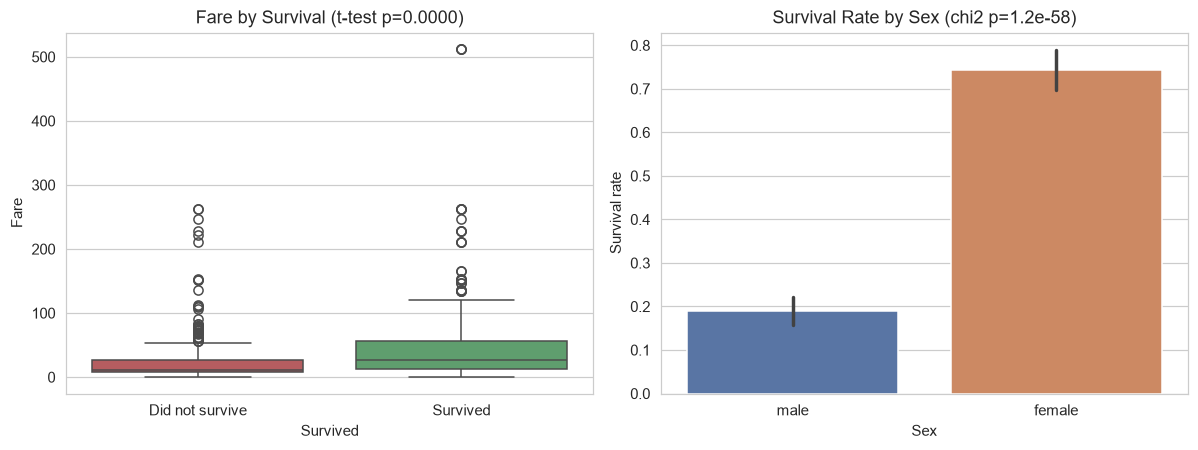

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.boxplot(x="Survived", y="Fare", data=df_clean, ax=axes[0], palette=["#C44E52", "#55A868"])
axes[0].set_title(f"Fare by Survival (t-test p={p_val_t:.4f})")
axes[0].set_xticklabels(["Did not survive", "Survived"])

sns.barplot(x="Sex", y="Survived", data=df_clean, ax=axes[1], palette=["#4C72B0", "#DD8452"])
axes[1].set_title(f"Survival Rate by Sex (chi2 p={p_val_chi2:.2g})")
axes[1].set_ylabel("Survival rate")

plt.tight_layout()
plt.savefig("hypothesis_tests.png")
plt.show()

## 5. Correlation vs Causation
Correlation shows association, **not** causal effect — see the discussion below the heatmap.

In [13]:
num_df = df_clean[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
corr = num_df.corr()
corr.round(3).to_csv("correlation_matrix.csv")
corr.round(3)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000,-0.338,-0.065,-0.035,0.082,0.257
Pclass,-0.338,1.000,-0.340,0.083,0.018,-0.549
Age,-0.065,-0.340,1.000,-0.233,-0.172,0.097
SibSp,-0.035,0.083,-0.233,1.000,0.415,0.160
Parch,0.082,0.018,-0.172,0.415,1.000,0.216
Fare,0.257,-0.549,0.097,0.160,0.216,1.000


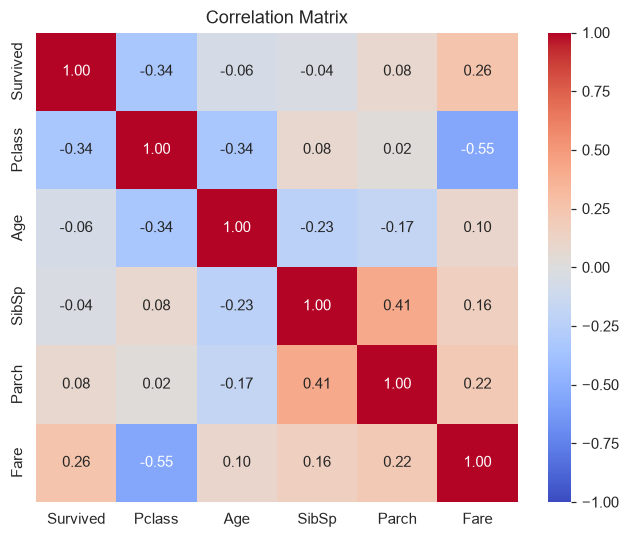

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

**Why correlation ≠ causation:**

- `Fare` and `Survived` are positively correlated, but a higher fare didn't *cause* survival. Passenger class (`Pclass`) is a confounder — first-class tickets cost more *and* first-class cabins were closer to the lifeboats.
- `Age` correlates with `Pclass` for a similar reason — wealthier, older passengers tended to travel first class, not because age itself determines ticket class.

Establishing real causation needs controlled experiments or causal inference methods — an observational dataset like this can only reveal association.